# SVM Exercises

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn import metrics

Load Pima diabetes dataset

In [ ]:
url = "https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week1/diabetes.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

data = pd.read_csv(url, names = names)
invalid = ['plas', 'pres', 'skin', 'test', 'mass']

for i in invalid:
    data[i].replace(to_replace=0, value=np.nan, inplace=True)

data = data.dropna(axis=0).reset_index(drop=True)

data.head()

/tmp/ipykernel_2041/1873102442.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[i].replace(to_replace=0, value=np.nan, inplace=True)


,preg,plas,pres,skin,test,mass,pedi,age,class
0,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
1,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
2,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
3,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
4,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1


Split data into training, colidation, and test sets with a test size of 25%

In [ ]:
# YOUR CODE HERE
X_cols = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']

y_col = 'class'

X_train, X_test, y_train, y_test = train_test_split(data[X_cols], data[y_col], test_size = 0.25, random_state = 0)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.2, random_state=0)

Create a model with sklearn's SVC and a high gamma value (perhaps 1.0)



In [ ]:
# YOUR CODE HERE
svm = SVC(gamma = 1, C= 1)
svm.fit(X_train, y_train)

SVC(C=1, gamma=1)

Print accuracy of training and validation data

In [ ]:
# YOUR CODE HERE
train_pred = svm.predict(X_train)
print(accuracy_score(y_train, train_pred))

val_pred = svm.predict(X_val)
print(accuracy_score(y_val, val_pred))

1.0
0.6779661016949152


Create a model with sklearn's SVC and a low gamma value (perhaps .001)

In [ ]:
# YOUR CODE HERE
svm2 = SVC(gamma = 0.001, C = 1)
svm2.fit(X_train, y_train)

SVC(C=1, gamma=0.001)

Print accuracy of training and validation data

In [ ]:
# YOUR CODE HERE
train_pred2 = svm2.predict(X_train)
print(accuracy_score(y_train, train_pred2))

val_pred2 = svm2.predict(X_val)
print(accuracy_score(y_val, val_pred2))

0.8638297872340426
0.7627118644067796


Explain the accuracy results below.

The first model overfit the data, as seen with the training score being at 1.0. This means that it was super complex to work perfect with its training data but didn't apply the same to the validation data.

The second model reduced this overfitting, reducing the training accuracy, but improving the validation accuracy.

Print the confusion matrices for your high and low gamma models (both numeric and visualized)

[[40  0]
 [19  0]]
[[39  1]
 [13  6]]


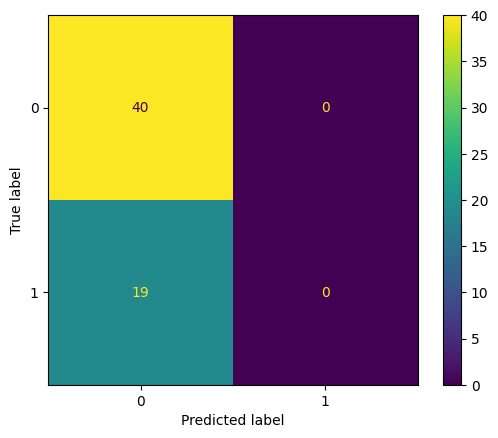

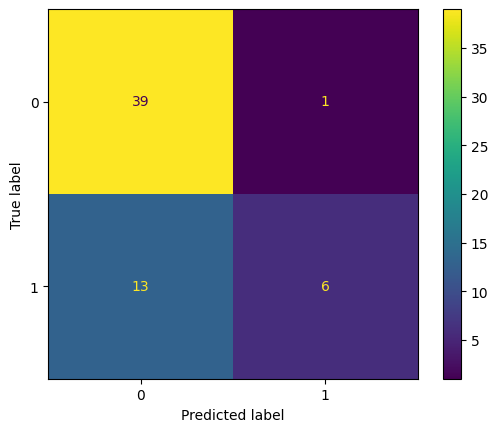

In [ ]:
# YOUR CODE HERE
cm = metrics.confusion_matrix(y_val, val_pred)
print(cm)

disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()

cm2 = metrics.confusion_matrix(y_val, val_pred2)
print(cm2)

disp2 = metrics.ConfusionMatrixDisplay(confusion_matrix = cm2)
disp2.plot()